## Importing Required Libraries

In this step, we import all the necessary libraries for data analysis, visualization, and model building.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Loading the Dataset

The dataset is loaded using pandas and basic inspection is performed.

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic Data Analysis

Understanding the structure and summary statistics of the dataset.

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

Handling missing values and removing unnecessary columns to prepare the dataset.

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df = df.dropna()
df = df.drop('customerID', axis=1)

## Data Visualization

Basic visualizations are performed to understand patterns and relationships in the data.

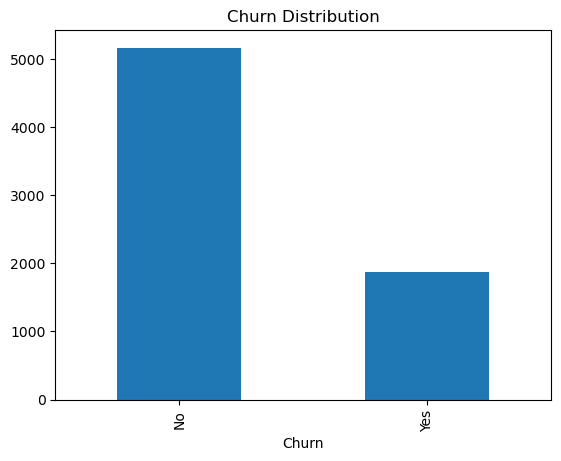

In [11]:
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.show()

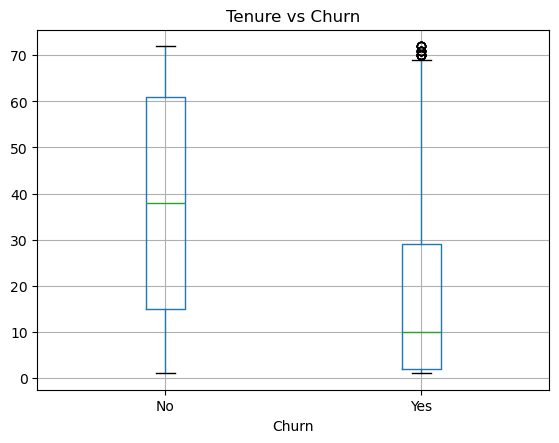

In [12]:
df.boxplot(column='tenure', by='Churn')
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.show()

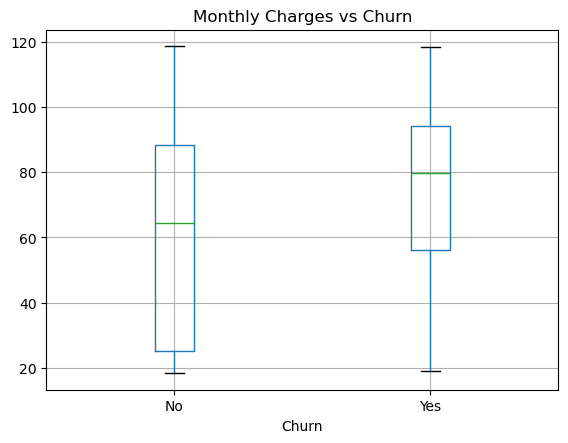

In [13]:
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.show()

## Data Encoding

Converting categorical variables into numerical format for model training.

In [14]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [15]:
df = pd.get_dummies(df, drop_first=True)
df = df.astype(int)

## Splitting the Data

Separating features and target variable and splitting the dataset into training and testing sets.

In [16]:
x = df.drop('Churn', axis=1)
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Checking Class Imbalance

Analyzing the distribution of the target variable to check for imbalance.

In [17]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## Applying SMOTE

SMOTE is used to handle class imbalance by generating synthetic samples for the minority class.

In [18]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

In [19]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_sm.value_counts())

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
1    4130
0    4130
Name: count, dtype: int64


## Model Building

Training Decision Tree and Random Forest models to predict customer churn.

In [20]:
dt = DecisionTreeClassifier(max_depth=10)
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

In [21]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [22]:
rf_sm = RandomForestClassifier(n_estimators=100, max_depth=10)
rf_sm.fit(x_train_sm, y_train_sm)

y_pred_rf_sm = rf_sm.predict(x_test)

## Model Comparison

Comparing the performance of different models using accuracy.

In [23]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest with SMOTE Accuracy:", accuracy_score(y_test, y_pred_rf_sm))

Decision Tree Accuracy: 0.7704335465529495
Random Forest Accuracy: 0.7896233120113717
Random Forest with SMOTE Accuracy: 0.7484008528784648


## Model Evaluation

Evaluating model performance using classification metrics.

In [24]:
print("Random Forest (Without SMOTE):")
print(classification_report(y_test, y_pred_rf))

Random Forest (Without SMOTE):
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.65      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [25]:
print("Random Forest (With SMOTE):")
print(classification_report(y_test, y_pred_rf_sm))

Random Forest (With SMOTE):
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.52      0.67      0.59       374

    accuracy                           0.75      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.75      0.76      1407



## Confusion Matrix

Visualizing model performance using a confusion matrix.

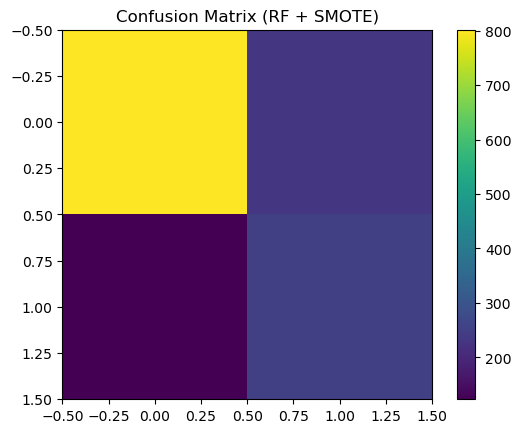

In [26]:
cm = confusion_matrix(y_test, y_pred_rf_sm)

plt.imshow(cm)
plt.title("Confusion Matrix (RF + SMOTE)")
plt.colorbar()
plt.show()

## Decision Tree Visualization

A simplified decision tree is plotted to understand decision rules.

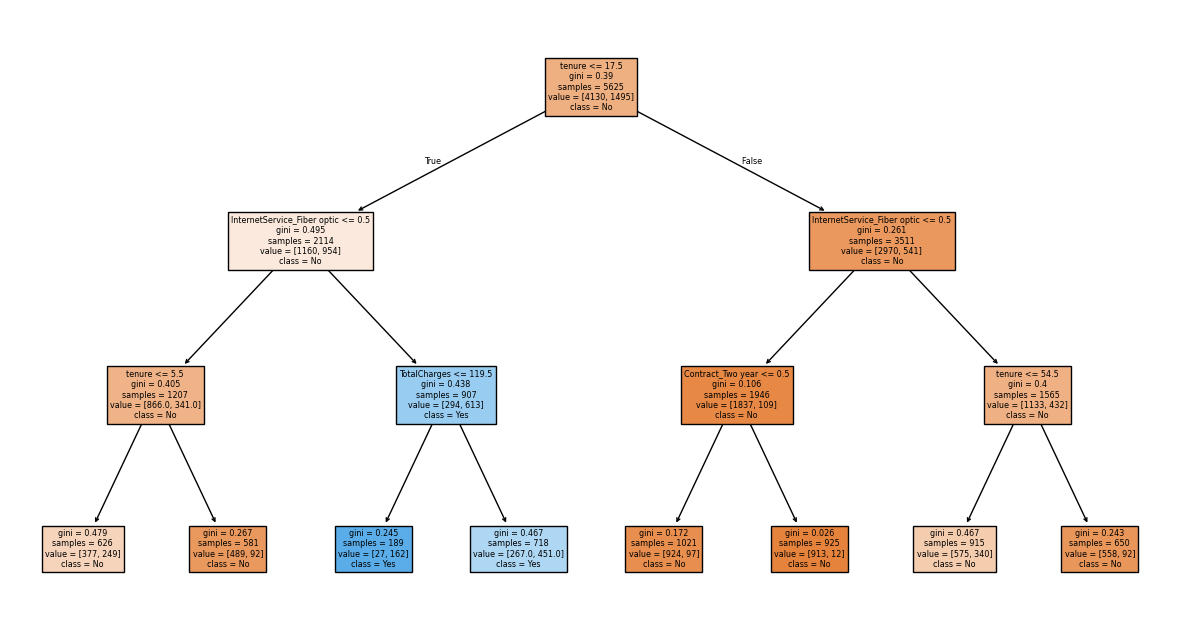

In [27]:
dt_small = DecisionTreeClassifier(max_depth=3)
dt_small.fit(x_train, y_train)

plt.figure(figsize=(15,8))
plot_tree(dt_small, feature_names=x.columns, class_names=['No','Yes'], filled=True)
plt.show()

## Feature Importance

Identifying the most important features influencing customer churn.

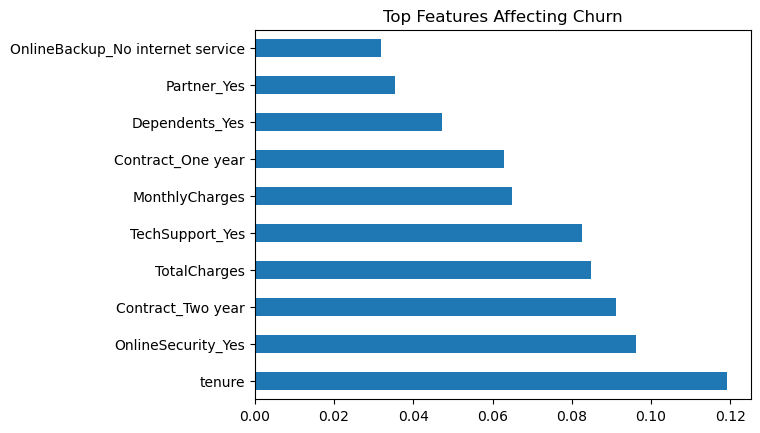

In [28]:
feat_imp = pd.Series(rf_sm.feature_importances_, index=x.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top Features Affecting Churn")
plt.show()

## Conclusion

Random Forest with SMOTE performed better in identifying churn customers. 
Although overall accuracy decreased slightly, recall for churn improved significantly, 
making the model more effective for real-world applications.